### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [3]:
data = pd.read_csv('data/coupons.csv')

In [4]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [5]:
data.shape
print("Missing values in each column:")
print(data.isnull().sum()[data.isnull().sum()>0])
freq_cols = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']
for col in freq_cols:
    print("% missing in", col, ":", round(data[col].isnull().mean()*100,2))



Missing values in each column:
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
dtype: int64
% missing in Bar : 0.84
% missing in CoffeeHouse : 1.71
% missing in CarryAway : 1.19
% missing in RestaurantLessThan20 : 1.02
% missing in Restaurant20To50 : 1.49


3. Decide what to do about your missing data -- drop, replace, other...

In [6]:
# Because the car column is missing 99% of values, I drop that column
data_clean = data.drop(columns=['car'])

#For the other columns, I will fill the missing values with the mode. I feel comfortable with this as the missing value rate is less than 2% for each of the remaining columns.

freq_cols = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']
for col in freq_cols:
    data_clean[col] = data_clean[col].fillna(data_clean[col].mode()[0])

# Print out remainder of missing values to check
print("Remaining missing values:", data_clean.isnull().sum().sum())

Remaining missing values: 0


4. What proportion of the total observations chose to accept the coupon?



In [7]:
accepted = data_clean['Y'].mean()
print(f"Proportion of coupons accepted: {accepted:.2%}")

Proportion of coupons accepted: 56.84%


5. Use a bar plot to visualize the `coupon` column.

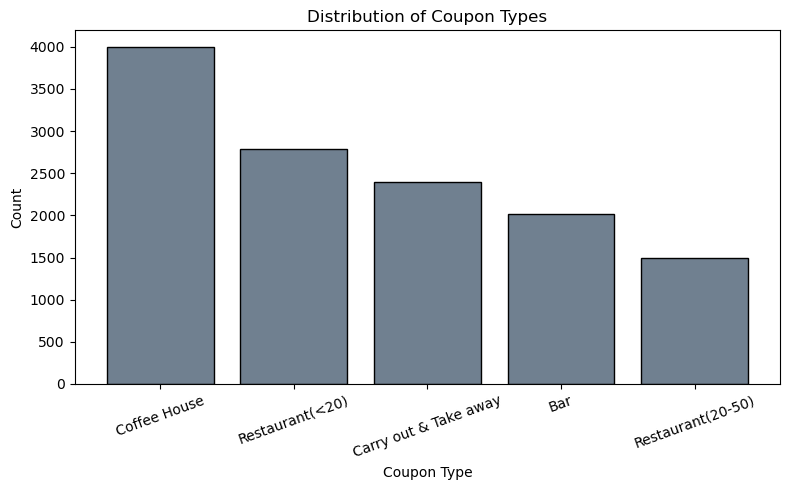

In [9]:
plt.figure(figsize=(8, 5))
coupon_counts = data_clean['coupon'].value_counts()
plt.bar(coupon_counts.index, coupon_counts.values, color='slategrey', edgecolor='black')
plt.title('Distribution of Coupon Types')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

6. Use a histogram to visualize the temperature column.

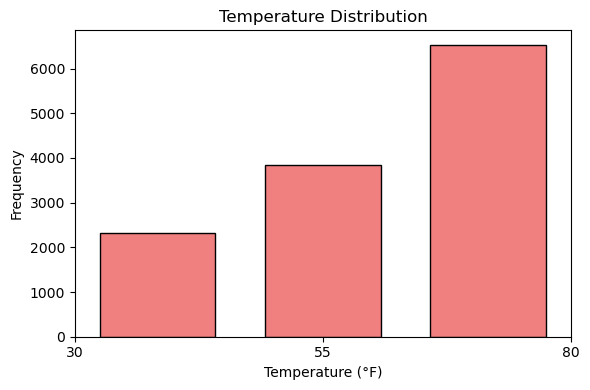

In [15]:
plt.figure(figsize=(6, 4))
plt.hist(data_clean['temperature'], bins=3, color='lightcoral', edgecolor='black', rwidth=0.7)
plt.title('Temperature Distribution')
plt.xlabel('Temperature (°F)')
plt.ylabel('Frequency')
plt.xticks([30, 55, 80])
plt.tight_layout()
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [16]:
bar_df = data_clean[data_clean['coupon'] == 'Bar'].copy()

bar_df.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1


2. What proportion of bar coupons were accepted?


In [17]:
bar_accept_rate = bar_df['Y'].mean()
print(f"Bar coupon acceptance rate: {bar_accept_rate:.2%}")

Bar coupon acceptance rate: 41.00%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [18]:
freq_order = {'never': 0, 'less1': 0.5, '1~3': 2, '4~8': 6, 'gt8': 9}
bar_df = bar_df.assign(bar_freq_num=bar_df['Bar'].map(freq_order))

low_freq  = bar_df[bar_df['bar_freq_num'] <= 3]['Y'].mean()
high_freq = bar_df[bar_df['bar_freq_num'] >  3]['Y'].mean()

print(f"Acceptance rate — bar visits <=3/month: {low_freq:.2%}")
print(f"Acceptance rate — bar visits  >3/month: {high_freq:.2%}")

Acceptance rate — bar visits <=3/month: 37.07%
Acceptance rate — bar visits  >3/month: 76.88%


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [20]:
age_order = {'below21': 18, '21': 21, '26': 26, '31': 31,
             '36': 36, '41': 41, '46': 46, '50plus': 55}
bar_df = bar_df.assign(age_num=bar_df['age'].map(age_order))

mask = (bar_df['bar_freq_num'] > 1) & (bar_df['age_num'] > 25)
print(f"Bar >1/mo AND age >25 : {bar_df[mask]['Y'].mean():.2%}")
print(f"All others            : {bar_df[~mask]['Y'].mean():.2%}")
#There does appear to be a difference of about 36.02%

Bar >1/mo AND age >25 : 69.52%
All others            : 33.50%


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [21]:
farming_occ = ['Farming Fishing & Forestry']
mask = (
    (bar_df['bar_freq_num'] > 1) &
    (bar_df['passanger'] != 'Kid(s)') &
    (~bar_df['occupation'].isin(farming_occ))
)
print(f"Bar>1/mo, no kids, not farming : {bar_df[mask]['Y'].mean():.2%}")
print(f"All others                     : {bar_df[~mask]['Y'].mean():.2%}")

Bar>1/mo, no kids, not farming : 71.32%
All others                     : 29.60%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [22]:
data_clean = data_clean.assign(
    bar_freq_num=data_clean['Bar'].map(freq_order),
    age_num=data_clean['age'].map(age_order),
    rest_freq_num=data_clean['RestaurantLessThan20'].map(freq_order)
)
bar_df = data_clean[data_clean['coupon'] == 'Bar'].copy()
income_under50k = ['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999']

group_A = bar_df[
    (bar_df['bar_freq_num'] > 1) &
    (bar_df['passanger'] != 'Kid(s)') &
    (bar_df['maritalStatus'] != 'Widowed')
]['Y'].mean()

group_B = bar_df[
    (bar_df['bar_freq_num'] > 1) &
    (bar_df['age_num'] < 30)
]['Y'].mean()

group_C = data_clean[
    (data_clean['rest_freq_num'] > 4) &
    (data_clean['income'].isin(income_under50k))
]['Y'].mean()

print(f"Group A (bar>1/mo, no kids, not widowed): {group_A:.2%}")
print(f"Group B (bar>1/mo, age <30)             : {group_B:.2%}")
print(f"Group C (cheap rest >4/mo, income <50k) : {group_C:.2%}")

Group A (bar>1/mo, no kids, not widowed): 71.32%
Group B (bar>1/mo, age <30)             : 72.17%
Group C (cheap rest >4/mo, income <50k) : 60.07%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [ ]:
#Hypothesis:
# Drivers who accept bar coupons tend to be frequent bar goers, under 30, have no kids, and not widowed. Bar coupon acceptance is driven primarily by these existing bar-going habits, younger age, and social context (i.e. marital status).

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [23]:
# Independent Investigation: Coffee House Coupons
coffee_df = data_clean[data_clean['coupon'] == 'Coffee House'].copy()
coffee_df = coffee_df.assign(coffee_freq_num=coffee_df['CoffeeHouse'].map(freq_order))

print(f"Coffee House overall acceptance rate: {coffee_df['Y'].mean():.2%}")

Coffee House overall acceptance rate: 49.92%


In [24]:
print("Acceptance by visit frequency:")
print(coffee_df.groupby('CoffeeHouse')['Y'].mean()
      .reindex(['never','less1','1~3','4~8','gt8'])
      .map('{:.2%}'.format))

print("\nAcceptance by time of day:")
print(coffee_df.groupby('time')['Y'].mean()
      .sort_values(ascending=False).map('{:.2%}'.format))

print("\nAcceptance by passenger type:")
print(coffee_df.groupby('passanger')['Y'].mean()
      .sort_values(ascending=False).map('{:.2%}'.format))

Acceptance by visit frequency:
CoffeeHouse
never    18.88%
less1    48.04%
1~3      64.78%
4~8      68.59%
gt8      65.79%
Name: Y, dtype: object

Acceptance by time of day:
time
10AM    64.07%
2PM     54.79%
7AM     44.58%
10PM    42.42%
6PM     41.26%
Name: Y, dtype: object

Acceptance by passenger type:
passanger
Friend(s)    59.69%
Partner      57.05%
Kid(s)       48.31%
Alone        43.79%
Name: Y, dtype: object


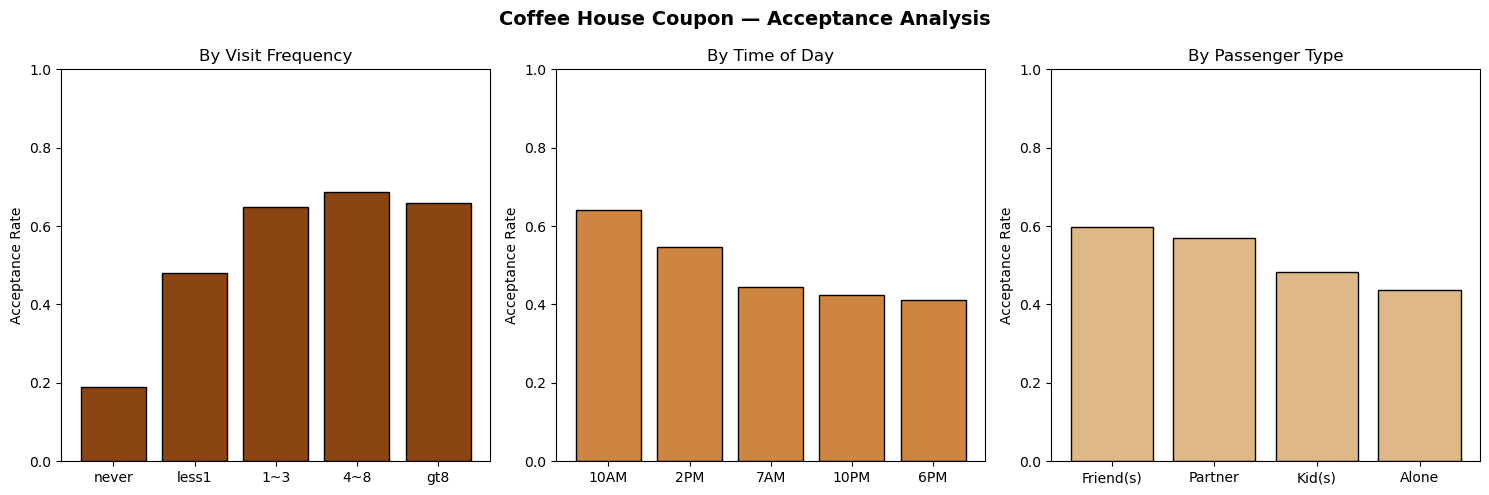

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Coffee House Coupon — Acceptance Analysis', fontsize=14, fontweight='bold')

ch_freq = coffee_df.groupby('CoffeeHouse')['Y'].mean().reindex(['never','less1','1~3','4~8','gt8'])
axes[0].bar(ch_freq.index, ch_freq.values, color='saddlebrown', edgecolor='black')
axes[0].set_title('By Visit Frequency')
axes[0].set_ylabel('Acceptance Rate')
axes[0].set_ylim(0, 1)

ch_time = coffee_df.groupby('time')['Y'].mean().sort_values(ascending=False)
axes[1].bar(ch_time.index, ch_time.values, color='peru', edgecolor='black')
axes[1].set_title('By Time of Day')
axes[1].set_ylabel('Acceptance Rate')
axes[1].set_ylim(0, 1)

ch_pass = coffee_df.groupby('passanger')['Y'].mean().sort_values(ascending=False)
axes[2].bar(ch_pass.index, ch_pass.values, color='burlywood', edgecolor='black')
axes[2].set_title('By Passenger Type')
axes[2].set_ylabel('Acceptance Rate')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()